# Book_Rating_Predictor

## Importing the necessary librairies

In [1]:
import pandas as pd
import numpy as np
import linecache
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis

I encountered a `ParserError` when loading the DataFrame because a few rows contain **13 features instead of the expected 12**. 

In [2]:
with open('books.csv', 'r', encoding='utf-8') as f:
    header = f.readline()
    expected_columns = len(header.split(','))

    print(f"Expected columns per row: {expected_columns}\n")
    print(f"--- Bad lines ---")
    
    for line_num, line in enumerate(f, start=2):
        current_columns = len(line.split(','))
        
        if current_columns != expected_columns:
            print(f"ParserError: Line {line_num} has {current_columns} columns (Expected {expected_columns})")

Expected columns per row: 12

--- Bad lines ---
ParserError: Line 3350 has 13 columns (Expected 12)
ParserError: Line 4704 has 13 columns (Expected 12)
ParserError: Line 5879 has 13 columns (Expected 12)
ParserError: Line 8981 has 13 columns (Expected 12)


In [3]:
header = linecache.getline("books.csv", 1)
line_numbers = [3350, 4704, 5879, 8981]

print(f"Header: {header}")

for num in line_numbers:
    line = linecache.getline("books.csv", num)
    print(f"Bad Line {num}: {line}")

linecache.clearcache()

Header: bookID,title,authors,average_rating,isbn,isbn13,language_code,  num_pages,ratings_count,text_reviews_count,publication_date,publisher

Bad Line 3350: 12224,Streetcar Suburbs: The Process of Growth in Boston  1870-1900,Sam Bass Warner, Jr./Sam B. Warner,3.58,0674842111,9780674842113,en-US,236,61,6,4/20/2004,Harvard University Press

Bad Line 4704: 16914,The Tolkien Fan's Medieval Reader,David E. Smith (Turgon of TheOneRing.net, one of the founding members of this Tolkien website)/Verlyn Flieger/Turgon (=David E. Smith),3.58,1593600119,9781593600112,eng,400,26,4,4/6/2004,Cold Spring Press

Bad Line 5879: 22128,Patriots (The Coming Collapse),James Wesley, Rawles,3.63,156384155X,9781563841552,eng,342,38,4,1/15/1999,Huntington House Publishers

Bad Line 8981: 34889,Brown's Star Atlas: Showing All The Bright Stars With Full Instructions How To Find And Use Them For Navigational Purposes And Department Of Trade Examinations.,Brown, Son & Ferguson,0.00,0851742718,9780851742717,eng,49,0

This happened because some author names have extra commas that trick `Pandas` into splitting a single column into two. 

To fix this, I used a dictionary mapping to clean up the formatting bugs on those specific lines so the dataset can load successfully.

In [4]:
corrections = {
    "Sam Bass Warner, Jr./Sam B. Warner": "Sam Bass Warner Jr.",
    "David E. Smith (Turgon of TheOneRing.net, one of the founding members of this Tolkien website)/Verlyn Flieger/Turgon (=David E. Smith)": "David E. Smith (Turgon)/Verlyn Flieger",
    "James Wesley, Rawles": "James Wesley Rawles",
    "Brown, Son & Ferguson": "Brown Son & Ferguson"
}

with open("books.csv", "r", encoding="utf-8", errors="ignore") as f:
    clean_lines = []
    for line in f:
        for wrong_text, correct_text in corrections.items():
            if wrong_text in line:
                line = line.replace(wrong_text, correct_text)
        clean_lines.append(line)

with open("books.csv", "w", encoding="utf-8") as f:
    f.writelines(clean_lines)

print("The books.csv file has been permanently fixed on your disk!")

The books.csv file has been permanently fixed on your disk!


Now, we can display the dataset to check our progress.

In [2]:
df = pd.read_csv('books.csv')

In [3]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


From the first look at the dataset, let's just fix the name of the author for the "Harry Potter" series to be just J.K. Rowling

In [4]:
df.replace(to_replace='J.K. Rowling/Mary GrandPré', value = 'J.K. Rowling', inplace=True)

In [5]:
df.shape

(11127, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11127 non-null  int64  
 1   title               11127 non-null  object 
 2   authors             11127 non-null  object 
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  object 
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  object 
 7     num_pages         11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  object 
 11  publisher           11127 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


Next, we will clean the dataset by removing all extra spaces from the column names and rows.

In [7]:
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)

Next, we will convert the data type of the `publication_date` column to a standard date format.

In [8]:
df['publication_date'] = pd.to_datetime(df['publication_date'], format='%m/%d/%Y', errors='coerce')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   bookID              11127 non-null  int64         
 1   title               11127 non-null  object        
 2   authors             11127 non-null  object        
 3   average_rating      11127 non-null  float64       
 4   isbn                11127 non-null  object        
 5   isbn13              11127 non-null  int64         
 6   language_code       11127 non-null  object        
 7   num_pages           11127 non-null  int64         
 8   ratings_count       11127 non-null  int64         
 9   text_reviews_count  11127 non-null  int64         
 10  publication_date    11125 non-null  datetime64[ns]
 11  publisher           11127 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(5)
memory usage: 1.0+ MB


We can now see that the `publication_date` column has two missing values.

In [10]:
df[df['publication_date'].isnull()]

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
8180,31373,In Pursuit of the Proper Sinner (Inspector Lyn...,Elizabeth George,4.10,0553575104,9780553575101,eng,718,10608,295,NaT,Bantam Books
11098,45531,Montaillou village occitan de 1294 à 1324,Emmanuel Le Roy Ladurie/Emmanuel Le Roy-Ladurie,3.96,2070323285,9782070323289,fre,640,15,2,NaT,Folio histoire


Rather than dropping records or using statistical imputation (like the median), we will look up the two missing book entries on `Goodreads` and fill them with their actual, correct publication dates.

In [11]:
df.loc[df['bookID'] == 31373, 'publication_date'] = '1/1/1999 00:00:00'
df.loc[df['bookID'] == 45531, 'publication_date'] = '1/1/1975 00:00:00'

df['publication_date'].isna().sum()

np.int64(0)

In [12]:
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,publication_date
count,11127.000000,11127.000000,1.112700e+04,11127.000000,1.112700e+04,11127.000000,11127
mean,21310.938887,3.933631,9.759888e+12,336.376921,1.793641e+04,541.854498,2000-08-27 15:37:13.378268928
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000,1900-01-01 00:00:00
25%,10287.000000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000,1998-07-16 12:00:00
50%,20287.000000,3.960000,9.780586e+12,299.000000,7.450000e+02,46.000000,2003-03-01 00:00:00
75%,32104.500000,4.135000,9.780873e+12,416.000000,4.993500e+03,237.500000,2005-09-30 00:00:00
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000,2020-03-31 00:00:00
std,13093.358023,0.352445,4.428964e+11,241.127305,1.124794e+05,2576.176608,NaN


* The `num_pages` column has a minimum value of 0, which is physically impossible for published books and represents missing or corrupted data. Similarly, a minimum `average_rating` and `ratings_count` of 0 indicate unrated items that could skew predictive performance.
* Columns tracking user engagement, particularly `ratings_count` and `text_reviews_count`, exhibit extreme right-skewness. A small fraction of highly popular books dominate the volume of engagement. Additionally, `num_pages` features a maximum outlier of 6,576 pages.

To prevent these anomalies from degrading the predictive power of our machine learning models, targeted data cleaning, imputation, and feature transformations will be applied.

Let's dig deeper into each feature to understand their distributions and discover patterns for our machine learning model.

In [13]:
df['publisher'].nunique()

2283

In [14]:
df['publisher'].str.lower().nunique()

2255

In [15]:
unique_publishers = df['publisher'].dropna().unique()

temp_series = pd.Series(unique_publishers)
duplicate_lower = temp_series.str.lower()[temp_series.str.lower().duplicated()]

print("--- Capitalization duplicates found ---")
for lower_name in duplicate_lower:
    matches = [pub for pub in unique_publishers if pub.lower() == lower_name]
    print(f"Lowercase: '{lower_name}' -> Original variations in  our data: {matches}")

--- Capitalization duplicates found ---
Lowercase: 'university of chicago press' -> Original variations in  our data: ['University of Chicago Press', 'University Of Chicago Press']
Lowercase: 'tarcherperigee' -> Original variations in  our data: ['Tarcherperigee', 'TarcherPerigee']
Lowercase: 'ballantine books' -> Original variations in  our data: ['Ballantine Books', 'BALLANTINE BOOKS']
Lowercase: 'macmillan audio' -> Original variations in  our data: ['MacMillan Audio', 'Macmillan Audio']
Lowercase: 'random house' -> Original variations in  our data: ['Random House', 'Random house']
Lowercase: 'debolsillo' -> Original variations in  our data: ['Debolsillo', 'DeBolsillo']
Lowercase: 'j'ai lu' -> Original variations in  our data: ["J'ai Lu", "J'ai lu", "J'AI LU"]
Lowercase: 'viz media' -> Original variations in  our data: ['VIZ Media', 'Viz Media']
Lowercase: 'eos' -> Original variations in  our data: ['Eos', 'EOS']
Lowercase: 'daw books' -> Original variations in  our data: ['Daw Book

In [16]:
df['publisher'] = df['publisher'].str.lower()

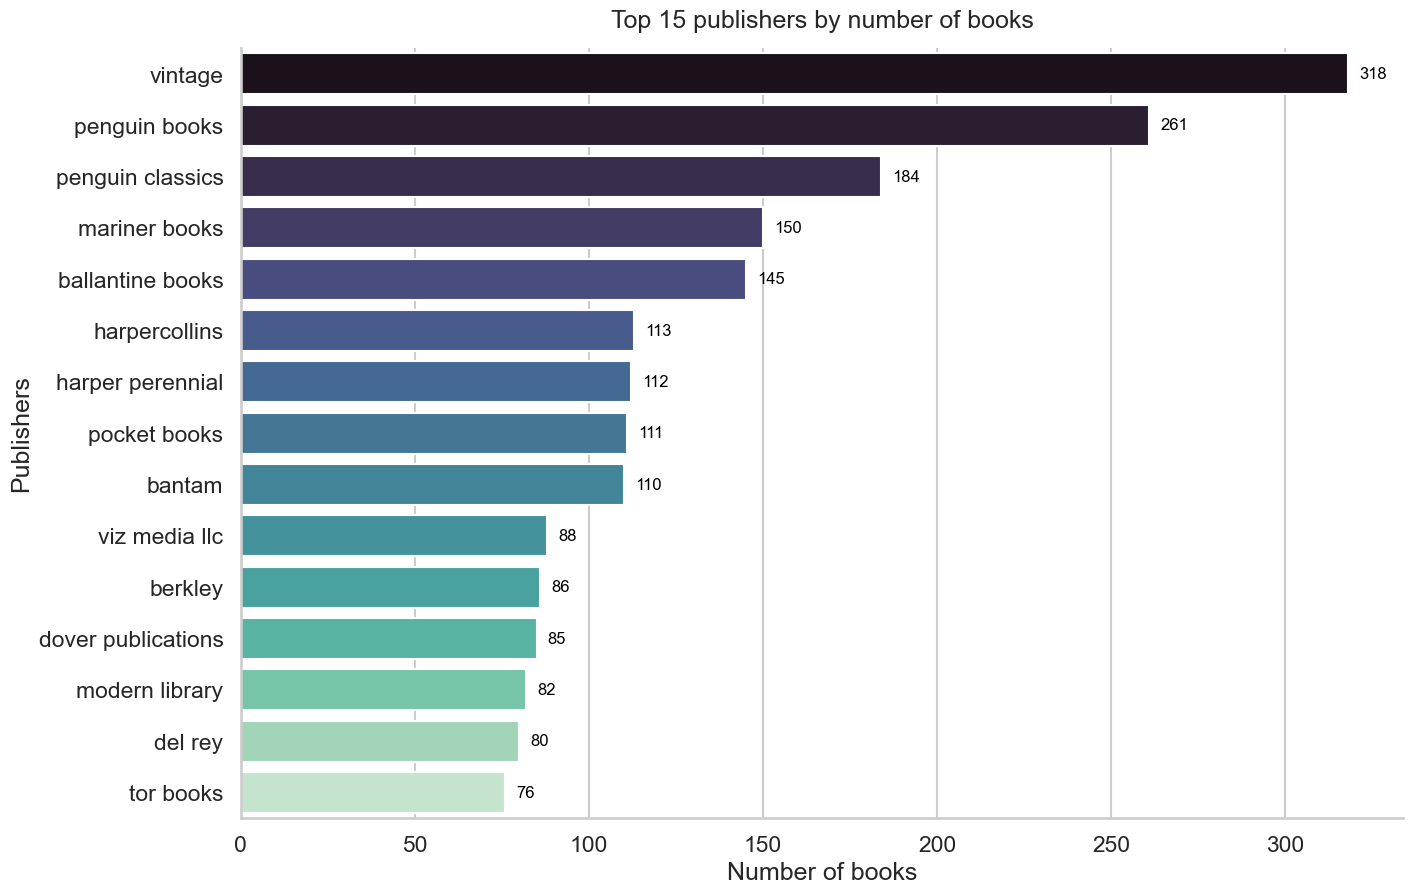

In [17]:
sns.set_context('talk')
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

publication_counts = df['publisher'].value_counts() 
top_publishers = publication_counts.head(15)

ax = sns.barplot(
    x=top_publishers.values, 
    y=top_publishers.index, 
    palette='mako',        
    hue=top_publishers.index,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, color='black')

ax.set_title('Top 15 publishers by number of books', pad=15)
ax.set_xlabel('Number of books')
ax.set_ylabel('Publishers')
sns.despine()

plt.show()

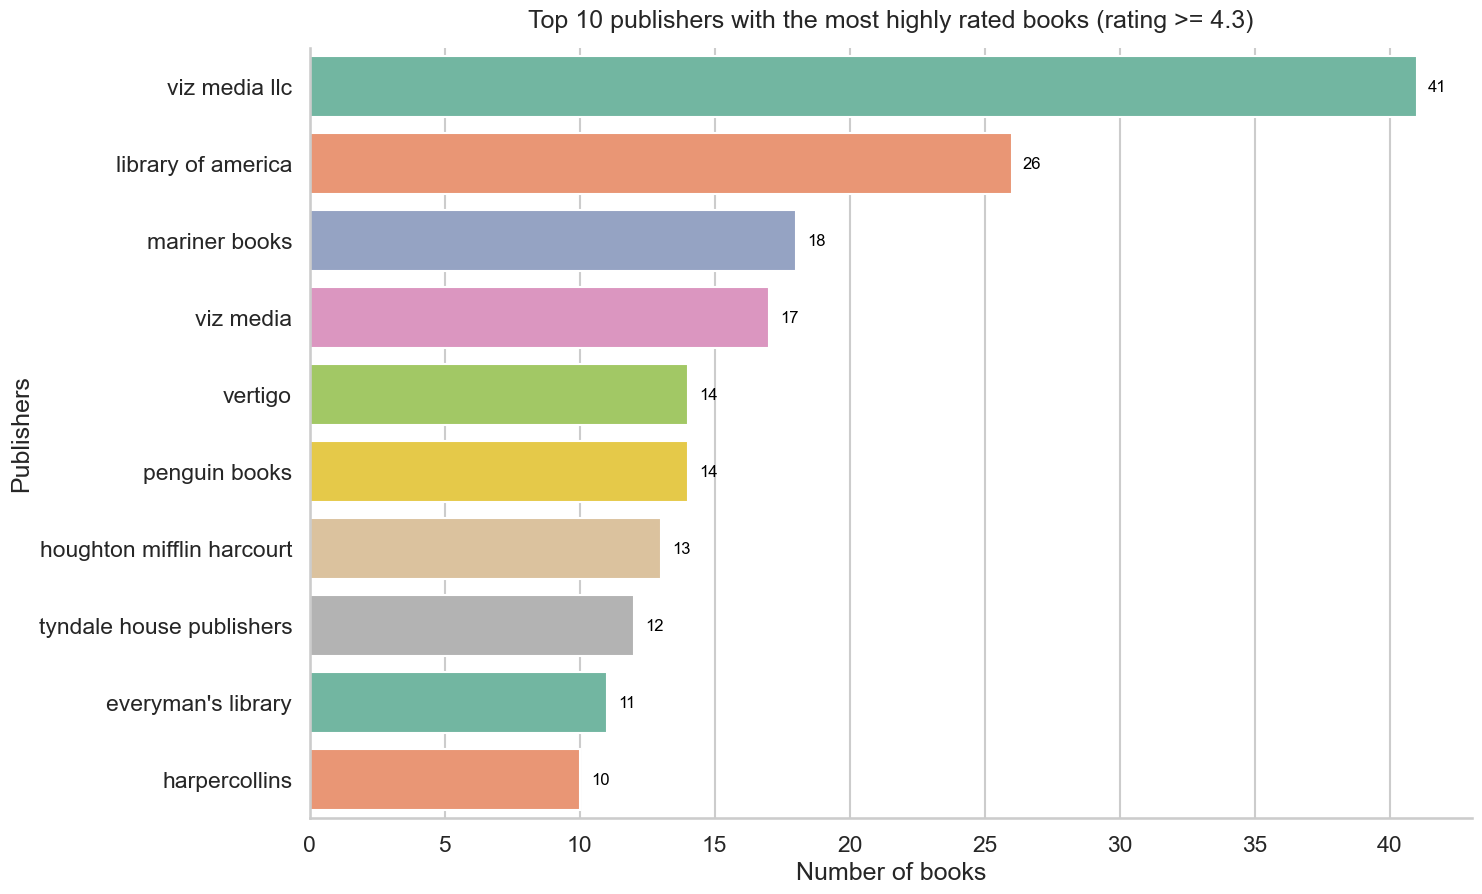

In [18]:
sns.set_context('talk')
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

high_rated_publishers = df[df['average_rating'] >= 4.3]['publisher'].value_counts().head(10)

ax = sns.barplot(
    x=high_rated_publishers.values, 
    y=high_rated_publishers.index, 
    palette='Set2',
    hue=high_rated_publishers.index, 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, color='black')

ax.set_title("Top 10 publishers with the most highly rated books (rating >= 4.3)", pad=15)
ax.set_xlabel("Number of books")
ax.set_ylabel("Publishers")
sns.despine()

plt.show()

In [19]:
columns = ['bookID', 'isbn', 'isbn13', 'title']

for col in columns :
    print(df[col].is_unique)

True
True
True
False


In [20]:
print(f"{df['title'].nunique()} books are unique out of {df['title'].shape[0]}")

10334 books are unique out of 11127


In [21]:
print(f"{df['title'].str.lower().nunique()} books are unique out of {df['title'].shape[0]}")

10295 books are unique out of 11127


In [22]:
unique_titles = df['title'].dropna().unique()

temp_series = pd.Series(unique_titles)
lower_series = temp_series.str.lower()

duplicate_lower = lower_series[lower_series.duplicated()].drop_duplicates()

print("--- Title Capitalization duplicates found ---")
for lower_name in duplicate_lower:
    matches = [title for title in unique_titles if title.lower() == lower_name]
    print(f"Lowercase: '{lower_name}' -> Original variations in our data: {matches}")

--- Title Capitalization duplicates found ---
Lowercase: 'the curious incident of the dog in the night-time' -> Original variations in our data: ['The Curious Incident of the Dog in the Night-Time', 'The Curious Incident of the Dog In the Night-time', 'The Curious Incident of the Dog in the Night-time']
Lowercase: 'personal finance for dummies' -> Original variations in our data: ['Personal Finance For Dummies', 'Personal Finance for Dummies']
Lowercase: 'east of eden' -> Original variations in our data: ['East of Eden', 'East Of Eden']
Lowercase: 'if i die in a combat zone' -> Original variations in our data: ['If I Die in a Combat Zone', 'If I Die In A Combat Zone']
Lowercase: 'a portrait of the artist as a young man' -> Original variations in our data: ['A Portrait of the Artist as a Young Man', 'A Portrait of the Artist As a Young Man']
Lowercase: 'one hundred years of solitude' -> Original variations in our data: ['One Hundred Years of Solitude', 'One Hundred Years Of Solitude']
L

In [23]:
df['title'] = df['title'].str.lower()

In [24]:
print(f"Unique titles: {df['title'].nunique()} out of {len(df)}")
print(f"Duplicate titles: {len(df) - df['title'].nunique()}")

Unique titles: 10295 out of 11127
Duplicate titles: 832


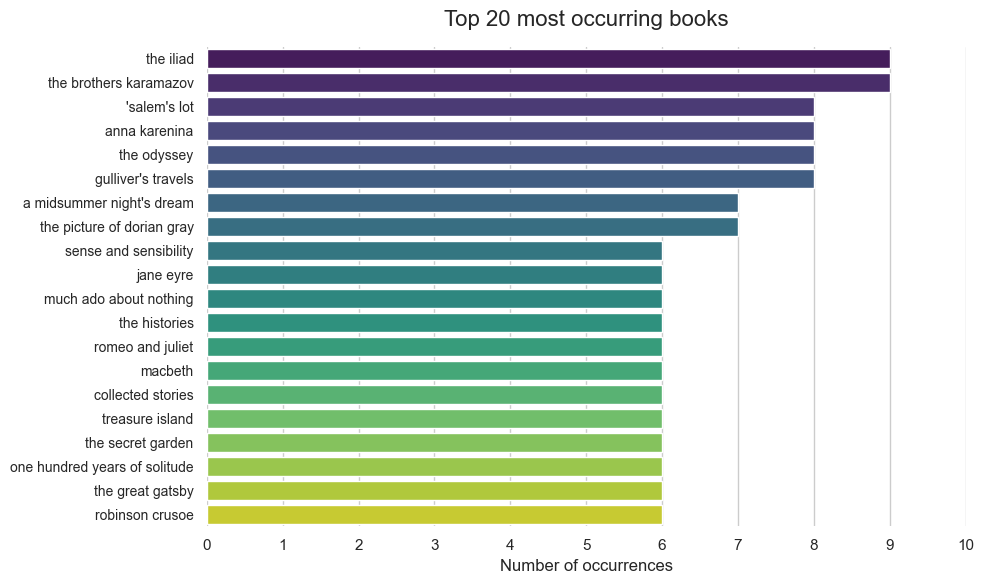

In [25]:
sns.set_theme(style="whitegrid", context="notebook")  
plt.figure(figsize=(10, 6)) 

top_books = df['title'].value_counts().head(20)

sns.barplot(
    x=top_books.values, 
    y=top_books.index, 
    palette="viridis",
    hue=top_books.index, 
    legend=False
)

max_val = top_books.max()
plt.xticks(range(0, max_val + 2, 1))  

plt.title("Top 20 most occurring books", fontsize=16, pad=15)
plt.xlabel("Number of occurrences", fontsize=12)
plt.ylabel("") 
plt.yticks(fontsize=10)  
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

The high occurrence of some titles like The Iliad and The Brothers Karamazov suggests that the dataset contains multiple different publications, translations, or duplicates of the exact same book.

If these widely-read classics carry systematically higher or lower ratings than average books, it could introduce a bias that skews our rating predictor; Our models will over-rely on popularity metrics instead of general book characteristics.

In [26]:
duplicate_books = df[df['title'].duplicated(keep=False)]

duplicate_books.sort_values(by='title')

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
1572,5413,'salem's lot,Stephen King/Jerry N. Uelsmann,4.25,0385516487,9780385516488,eng,594,84123,571,2005-11-01,doubleday
1573,5414,'salem's lot,Stephen King/Ron McLarty,4.02,0743536967,9780743536967,eng,17,227,54,2004-01-19,simon & schuster audio
1574,5415,'salem's lot,Stephen King,4.02,0965772411,9780965772419,eng,405,1039,130,1975-10-17,doubleday
1576,5419,'salem's lot,Stephen King,4.02,0451092317,9780451092311,en-US,427,178,35,1979-11-13,signet
5302,19137,'salem's lot,Stephen King,4.02,0451098277,9780451098276,eng,817,18,3,1976-08-01,signet
...,...,...,...,...,...,...,...,...,...,...,...,...
10908,44597,wide sargasso sea,Jean Rhys,3.58,0140274219,9780140274219,eng,160,21384,1386,1998-09-03,penguin books
568,1848,wild swans: three daughters of china,Jung Chang,4.26,0743246985,9780743246989,eng,562,73572,4280,2003-08-12,simon schuster
2656,9763,wild swans: three daughters of china,Jung Chang,4.26,0007176155,9780007176151,eng,666,1832,214,2004-04-05,harper perennial
3492,12703,wuthering heights,Emily Brontë/Alice Hoffman,3.85,0451529251,9780451529251,eng,322,1898,201,2004-03-02,signet classics


Here we can see same books with multi-edition duplicates and different ratings and publications dates.

We have to choose between two evils:
* **Evil A (Keeping all editions)**: Our models get to see all the different features for the same book, but they overtrain, break their math for example on page counts, and hallucinates popularity because the same book is repeated 12 times.
* **Evil B (Keeping only the top edition)**: The model loses some minor variations, but the data becomes perfectly clean, uniform, and completely safe from overtraining.

Evil B is by far the lesser evil. So, we keep the one with the highest number of ratings since it represents the version most readers actually interacted with.

In [27]:
duplicate_books_sorted = duplicate_books.sort_values(by='ratings_count', ascending=False)

retained_books = duplicate_books_sorted.drop_duplicates(subset=['title'], keep='first')

Those are the rows that we want to keep. Now, we need to drop the other rows from our dataset.

In [28]:
retained_books.sort_values(by='title')

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
1572,5413,'salem's lot,Stephen King/Jerry N. Uelsmann,4.25,0385516487,9780385516488,eng,594,84123,571,2005-11-01,doubleday
326,1067,1776,David McCullough,4.07,0743226720,9780743226721,eng,386,166916,6243,2006-07-04,simon schuster
1586,5477,1984,George Orwell/Erich Fromm,4.18,0451516753,9780451516756,eng,268,1322,121,1981-07-01,signet classics
8551,32830,20 000 leagues under the sea,Pauline Francis/Jules Verne,3.76,0237526883,9780237526887,eng,48,563,32,2004-08-01,evans brothers
3629,13136,2nd chance (women's murder club #2),James Patterson/Andrew Gross,4.04,0446696633,9780446696630,eng,400,78780,2118,2005-05-20,grand central publishing
...,...,...,...,...,...,...,...,...,...,...,...,...
8377,32234,white oleander,Janet Fitch,3.96,0316182540,9780316182546,eng,446,301784,6170,2001-09-01,little brown and company
1098,3711,white teeth,Zadie Smith,3.77,0375703861,9780375703867,eng,448,102370,5677,2001-06-12,vintage
10908,44597,wide sargasso sea,Jean Rhys,3.58,0140274219,9780140274219,eng,160,21384,1386,1998-09-03,penguin books
568,1848,wild swans: three daughters of china,Jung Chang,4.26,0743246985,9780743246989,eng,562,73572,4280,2003-08-12,simon schuster


In [29]:
all_duplicate_indices = df[df['title'].duplicated(keep=False)].index

indices_to_drop = all_duplicate_indices.difference(retained_books.index)

df = df.drop(indices_to_drop)

In [30]:
df.shape

(10295, 12)

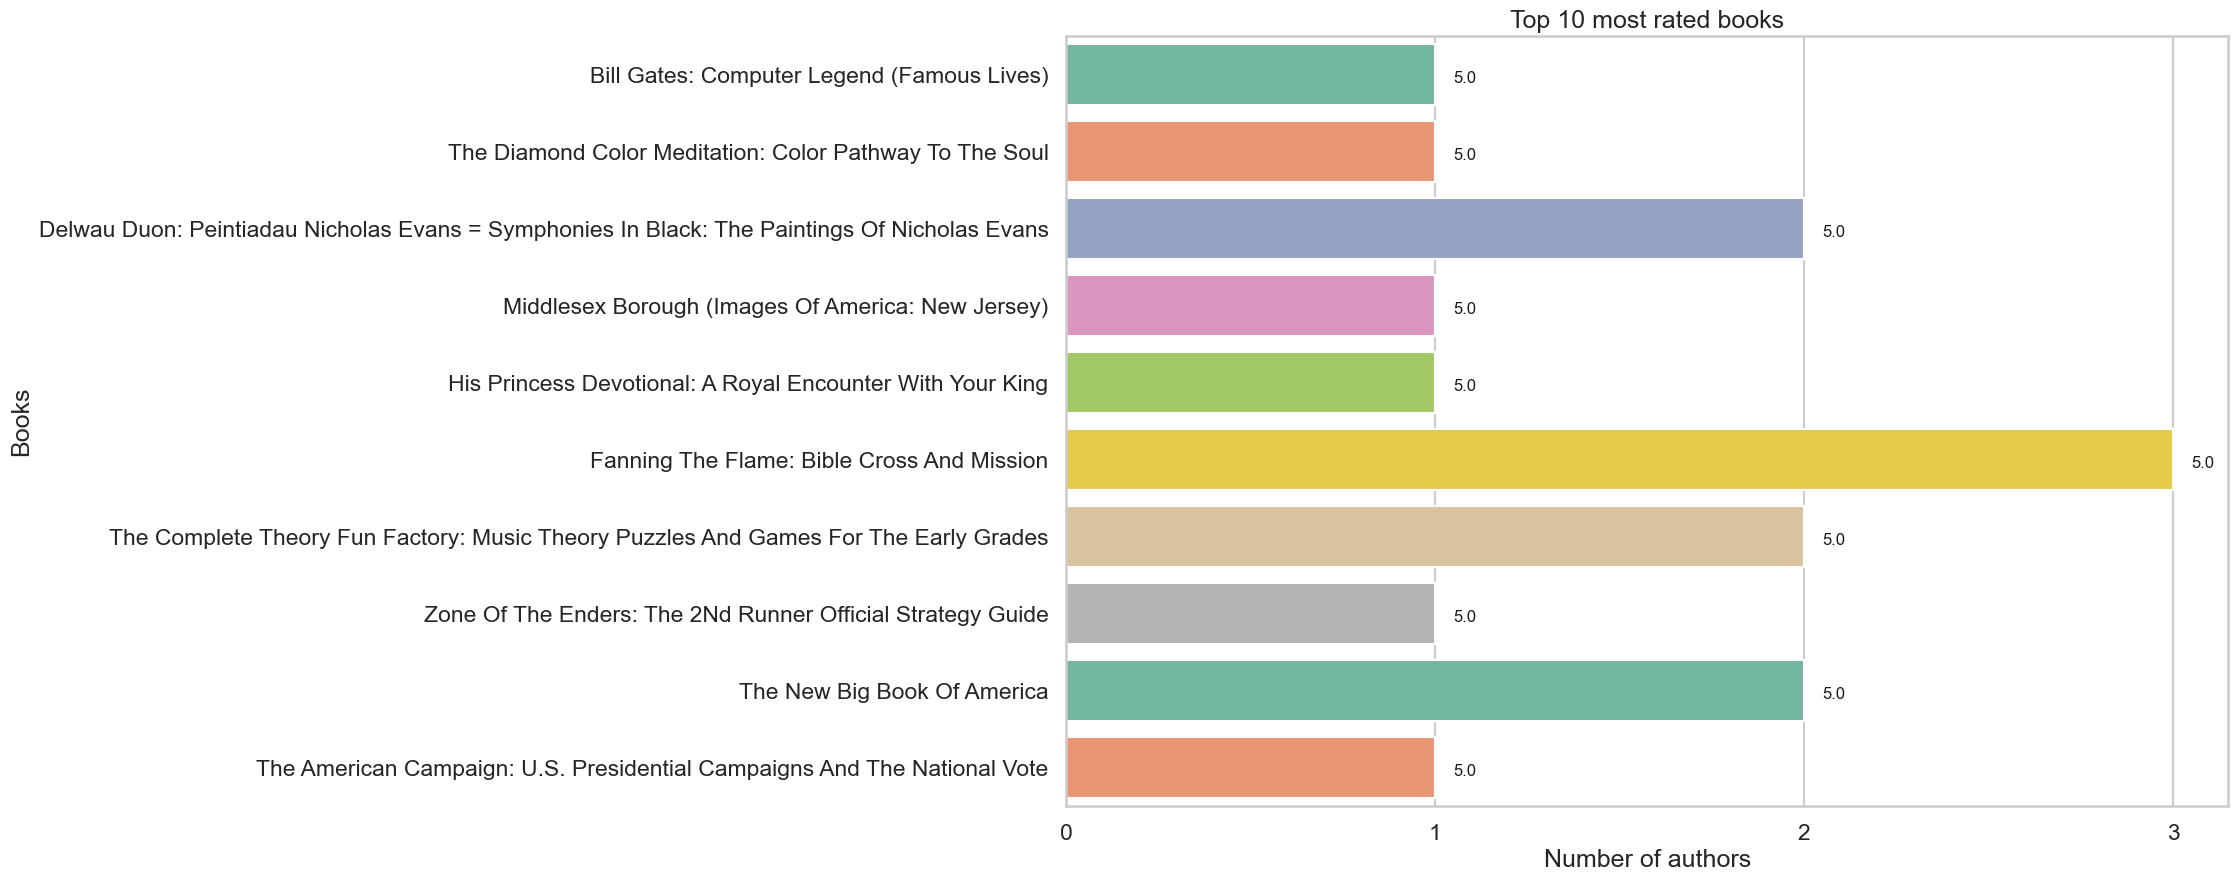

In [31]:
from matplotlib.ticker import MaxNLocator

sns.set_context('talk')
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

top_10_rated = df.sort_values(by='average_rating', ascending=False).head(10)
num_authors = top_10_rated['authors'].str.split('/').str.len()
book_titles = top_10_rated['title'].str.title()

ax = sns.barplot(x=num_authors, y=book_titles, palette='Set2')

for i, patch in enumerate(ax.patches):
    rating_val = top_10_rated['average_rating'].iloc[i]
    
    ax.text(patch.get_width() + 0.05, patch.get_y() + 0.5, str(rating_val), fontsize=12, color='k')

plt.title("Top 10 most rated books")
plt.xlabel("Number of authors")
plt.ylabel("Books")

ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [32]:
print(f"{df['authors'].nunique()} books are unique out of {df['authors'].shape[0]}")

6257 books are unique out of 10295


In [33]:
print(f"{df['authors'].str.lower().nunique()} books are unique out of {df['authors'].shape[0]}")

6257 books are unique out of 10295


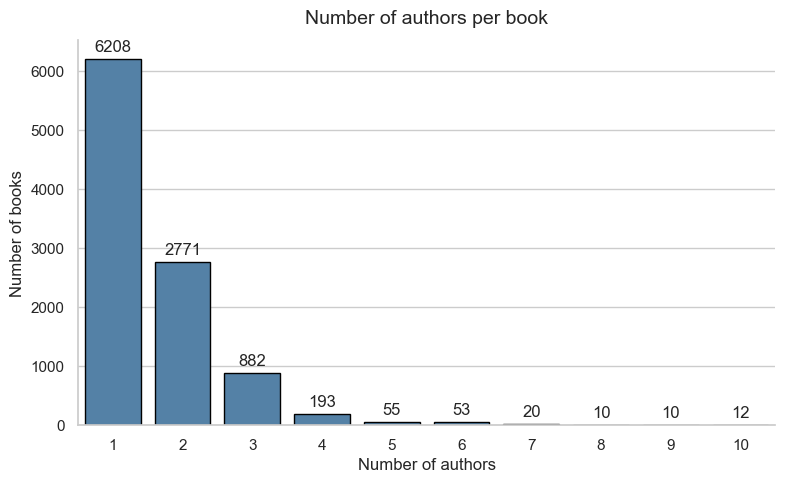

In [34]:
sns.set_theme(style="whitegrid", context="notebook")

author_counts = df['authors'].str.split('/').str.len().value_counts().sort_index().head(10)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=author_counts.index.astype(int), 
    y=author_counts.values,
    color='steelblue', 
    edgecolor='black'
)

ax.bar_label(ax.containers[0], padding=3)

plt.title('Number of authors per book', fontsize=14, pad=12)
plt.xlabel('Number of authors', fontsize=12)
plt.ylabel('Number of books', fontsize=12)

sns.despine()
plt.show()

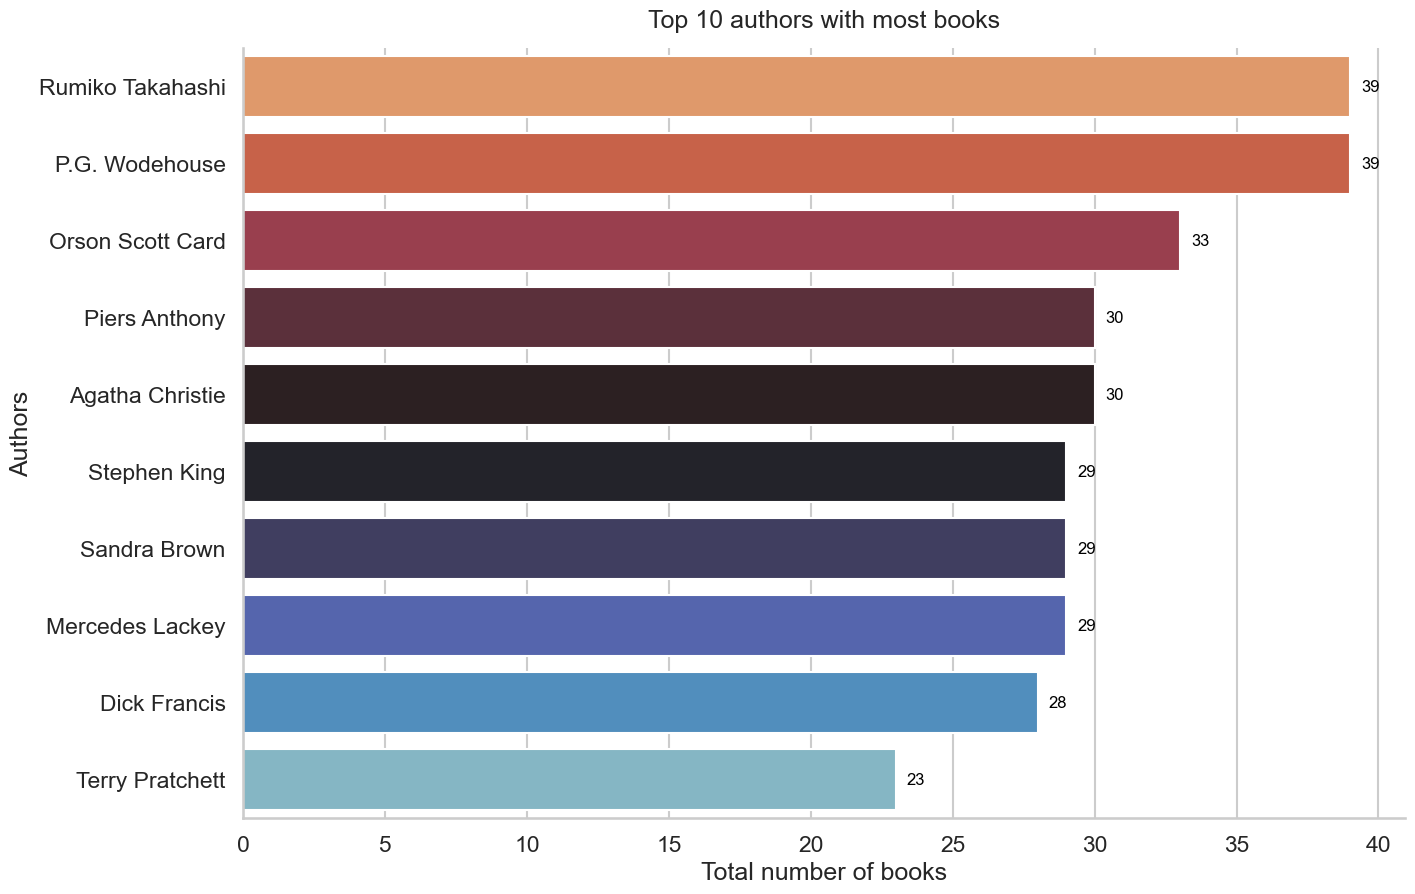

In [35]:
sns.set_context('talk')
sns.set_style("whitegrid")

top_authors = df['authors'].value_counts().head(10)

plt.figure(figsize=(15, 10))
ax = sns.barplot(
    x=top_authors.values, 
    y=top_authors.index, 
    palette='icefire_r',
    hue=top_authors.index,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, color='black')

ax.set_title("Top 10 authors with most books", pad=15)
ax.set_xlabel("Total number of books")
ax.set_ylabel("Authors")
sns.despine()

plt.show()

A small group of authors have a ton of books in this dataset. Because their names pop up so often, our machine learning models will easily recognize them. This means their specific author names will likely be a strong hint for predicting book ratings.

While these 10 authors have a lot of books, there are probably thousands of other authors who only have 1 book each.

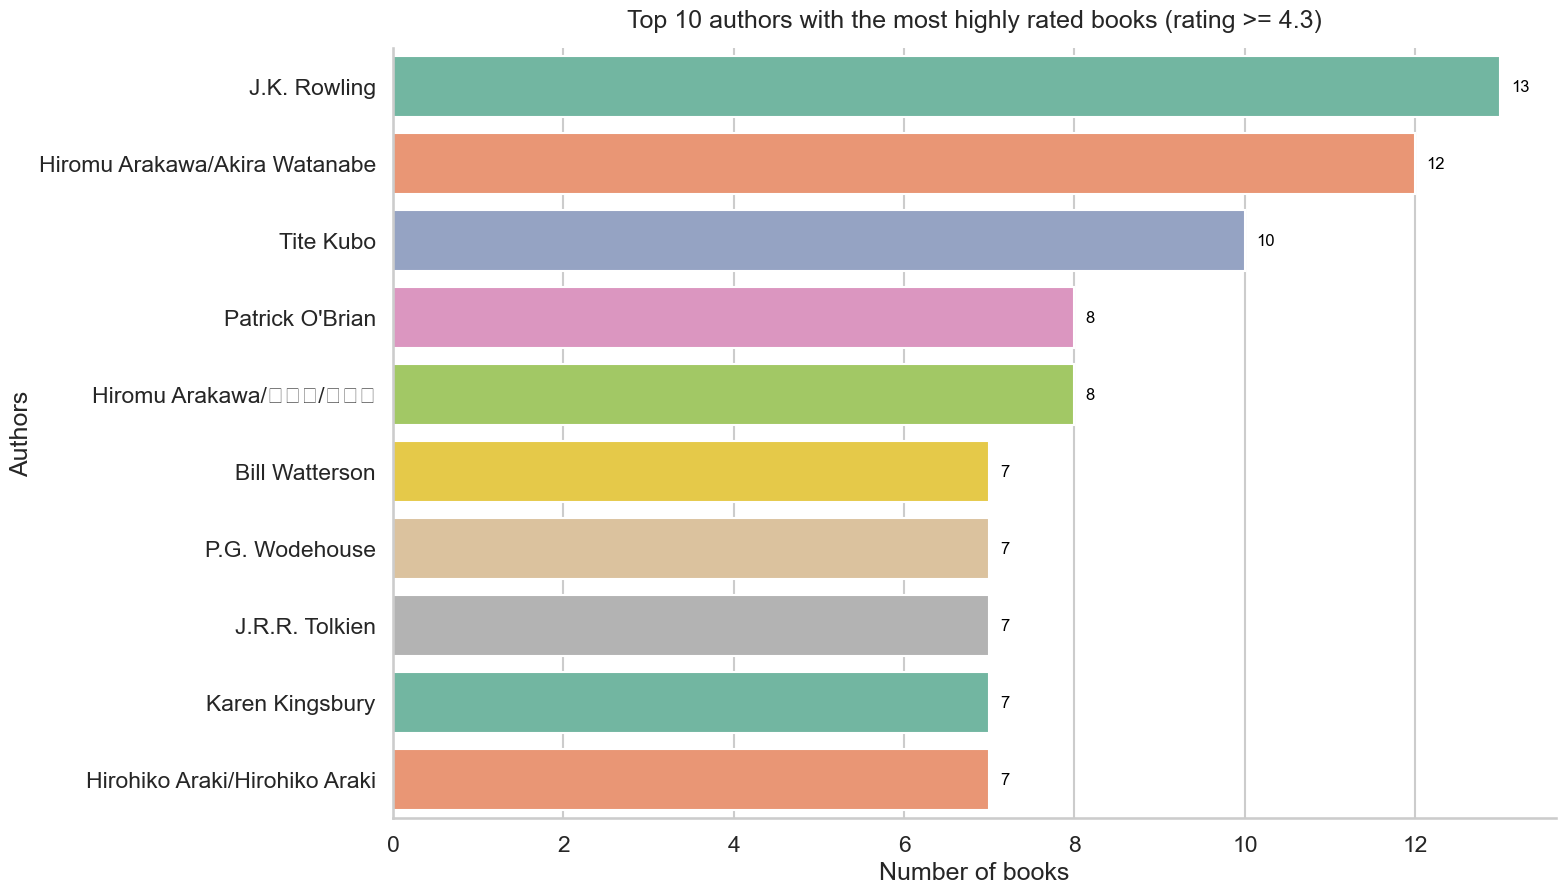

In [36]:
sns.set_context('talk')
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

high_rated_authors = df[df['average_rating'] >= 4.3]['authors'].value_counts().head(10)

ax = sns.barplot(
    x=high_rated_authors.values, 
    y=high_rated_authors.index, 
    palette='Set2',
    hue=high_rated_authors.index, 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, color='black')

ax.set_title("Top 10 authors with the most highly rated books (rating >= 4.3)", pad=15)
ax.set_xlabel("Number of books")
ax.set_ylabel("Authors")
sns.despine()

plt.show()

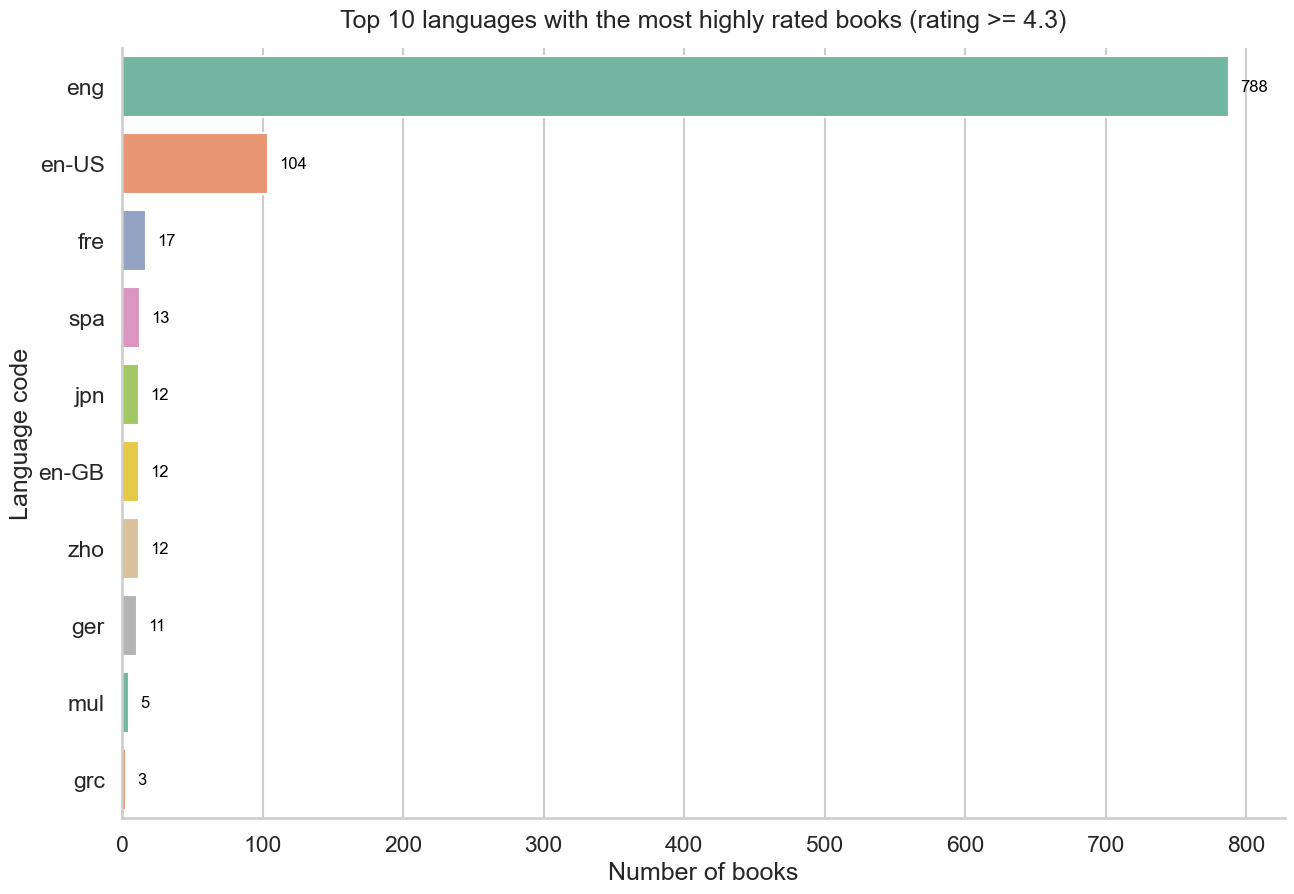

In [37]:
sns.set_context('talk')
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

high_rated_languages = df[df['average_rating'] >= 4.3]['language_code'].value_counts().head(10)

ax = sns.barplot(
    x=high_rated_languages.values, 
    y=high_rated_languages.index, 
    palette='Set2',
    hue=high_rated_languages.index, 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, color='black')

ax.set_title("Top 10 languages with the most highly rated books (rating >= 4.3)", pad=15)
ax.set_xlabel("Number of books")
ax.set_ylabel("Language code")
sns.despine()

plt.show()

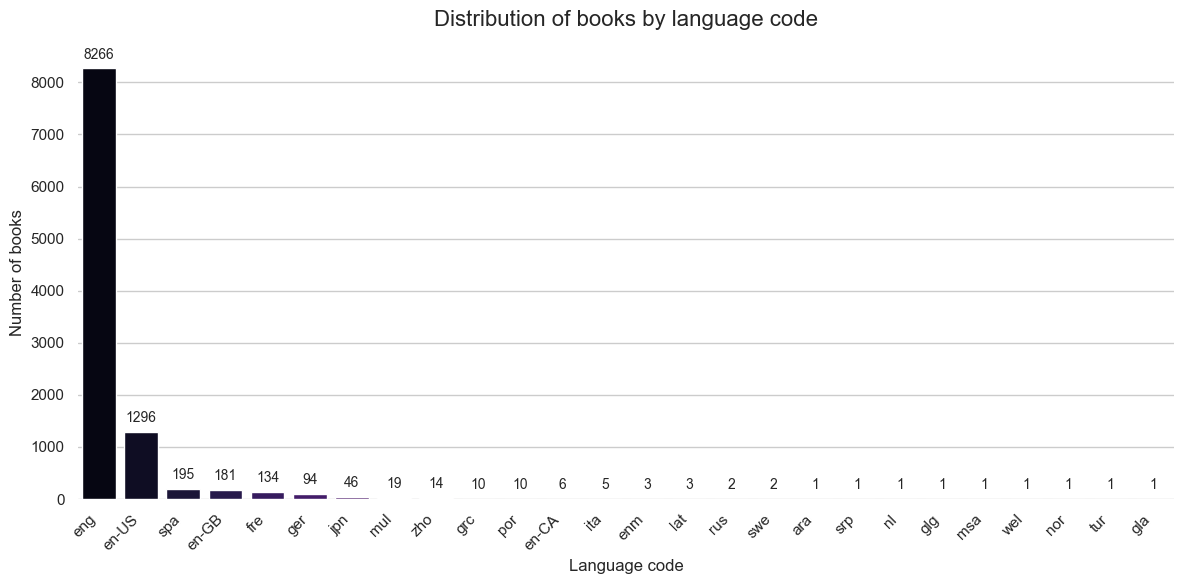

In [38]:
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(12, 6))

lang_counts = df['language_code'].value_counts()

ax = sns.barplot(
    x=lang_counts.index, 
    y=lang_counts.values, 
    palette="magma",
    hue=lang_counts.index,
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', 
            va='bottom', 
            fontsize=10, 
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.title('Distribution of books by language code', fontsize=16, pad=15)
plt.xlabel('Language code', fontsize=12)
plt.ylabel('Number of books', fontsize=12)
plt.xticks(rotation=45, ha='right')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The dataset is so heavily skewed toward English, any machine learning model we train on this raw data will be highly optimized for English books but may fail to accurately predict ratings for other languages.

The 15+ languages that appear less than 20 times  do not provide enough statistical volume for an algorithm to learn meaningful patterns. If left completely unhandled, these rare categorical values will act as noisy variables or could break our training pipeline.

So to avoid that, let's just keep the top 7 languages with the most occurences.

In [39]:
languages_to_keep = ['eng', 'en-US', 'spa', 'en-GB', 'fre', 'ger', 'jpn']

df = df[df['language_code'].isin(languages_to_keep)]

In [40]:
df.shape

(10212, 12)

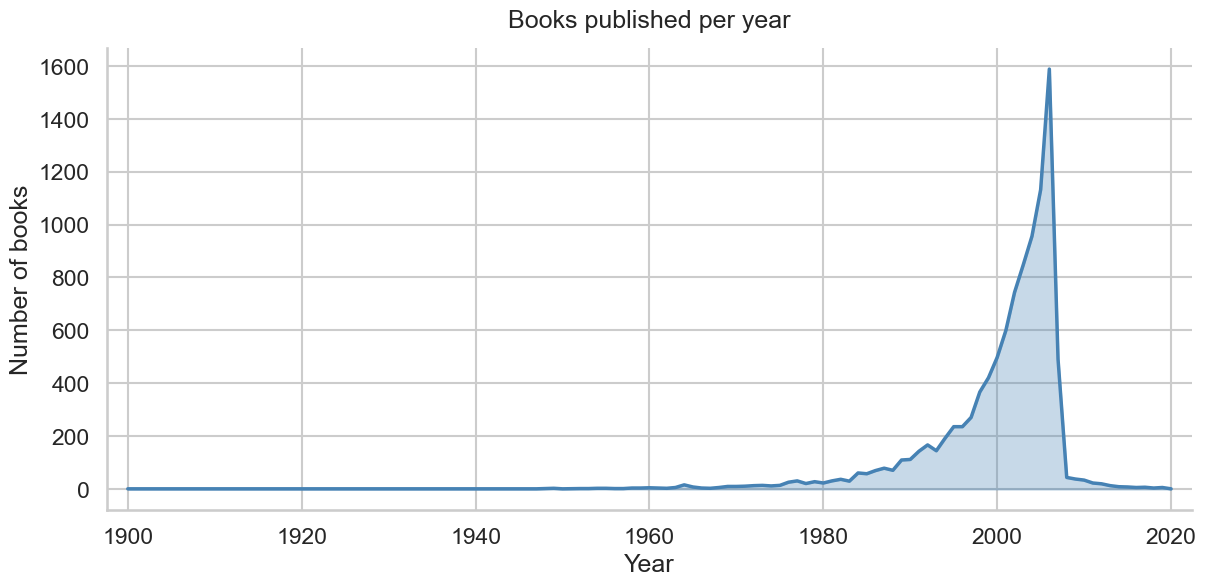

In [41]:
sns.set_context('talk')
sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

publication_year = df['publication_date'].dt.year
all_year_counts = publication_year.dropna().astype(int).value_counts().sort_index()

sns.lineplot(
    x=all_year_counts.index, 
    y=all_year_counts.values, 
    color='steelblue', 
    linewidth=2.5
)

plt.fill_between(
    all_year_counts.index, 
    all_year_counts.values, 
    color='steelblue', 
    alpha=0.3
)

plt.title('Books published per year', pad=15)
plt.xlabel('Year')
plt.ylabel('Number of books')

plt.margins(x=0.02) 
sns.despine()

plt.show()

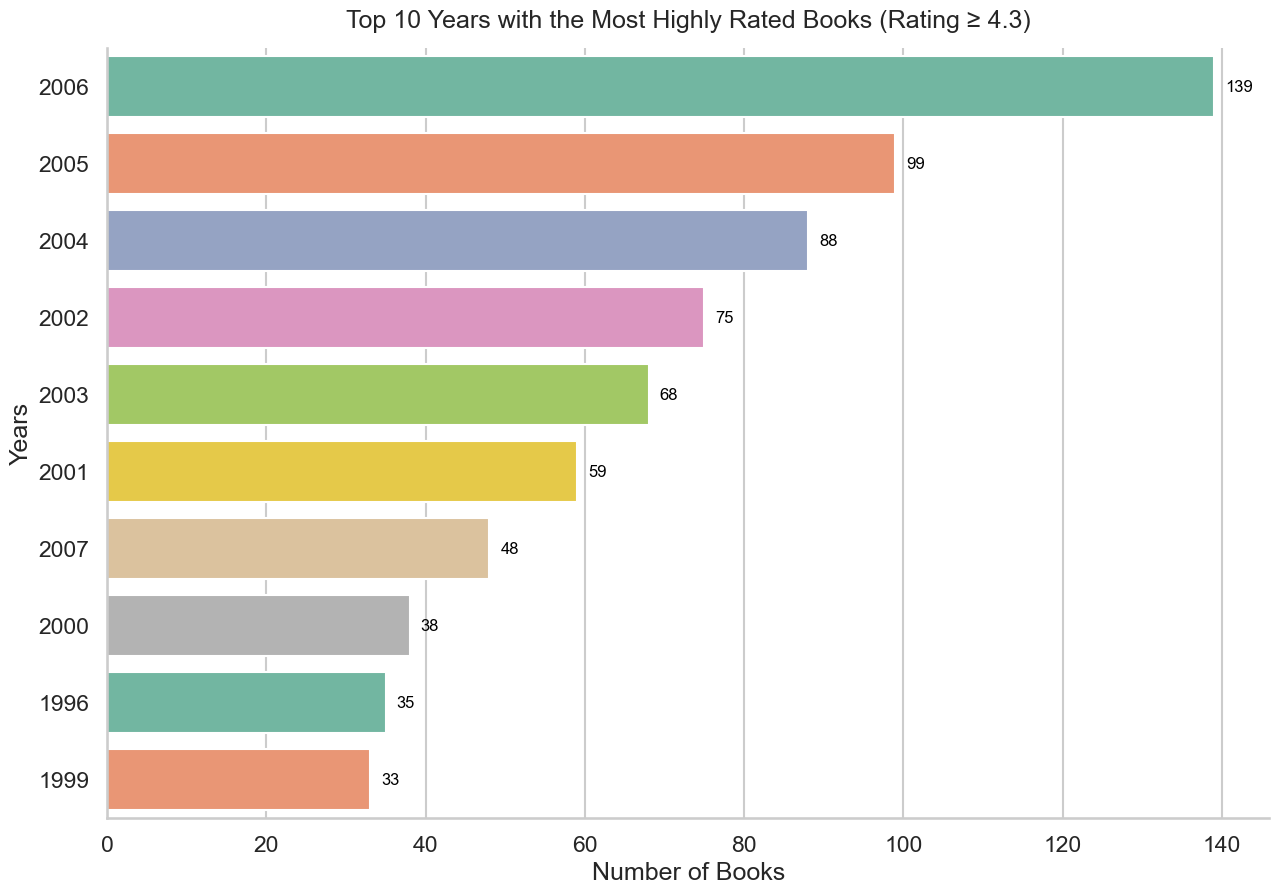

In [42]:
sns.set_context('talk')
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

high_rated_years = df[df['average_rating'] >= 4.3]['publication_date'].dt.year.dropna().astype(int).value_counts().head(10)

ax = sns.barplot(
    x=high_rated_years.values,    
    y=high_rated_years.index.astype(str), 
    palette='Set2',
    hue=high_rated_years.index.astype(str),
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=8, fontsize=12, color='black')

ax.set_title("Top 10 Years with the Most Highly Rated Books (Rating ≥ 4.3)", pad=15)
ax.set_xlabel("Number of Books")
ax.set_ylabel("Years")
sns.despine()

plt.show()

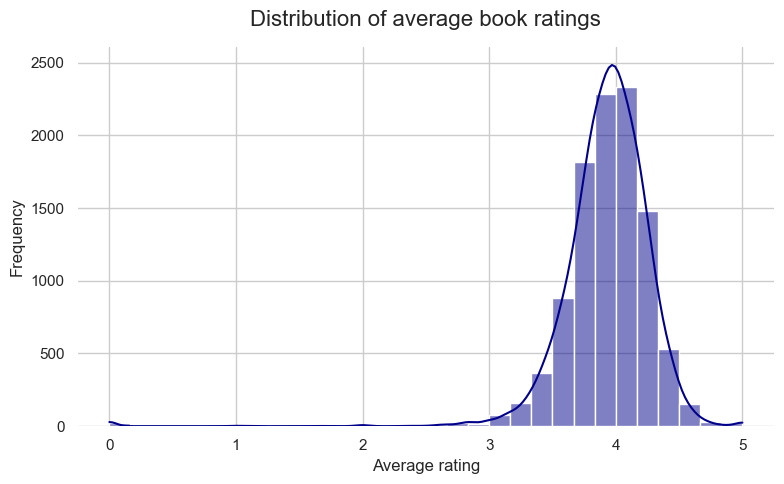

In [43]:
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(8, 5))

sns.histplot(df['average_rating'], kde=True, bins=30, color='darkblue')

plt.title('Distribution of average book ratings', fontsize=16, pad=15)
plt.xlabel('Average rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

The target variable is highly concentrated between 3.5 and 4.5, traditional machine learning models may suffer from a central tendency bias. The models will likely become excellent at predicting average scores but struggle to accurately detect truly poorly rated or exceptionally rated books.

The small bump at 0.0 is highly likely to be a structural absence of data. Leaving these 0.0 values in the dataset could severely distort the models' loss function.

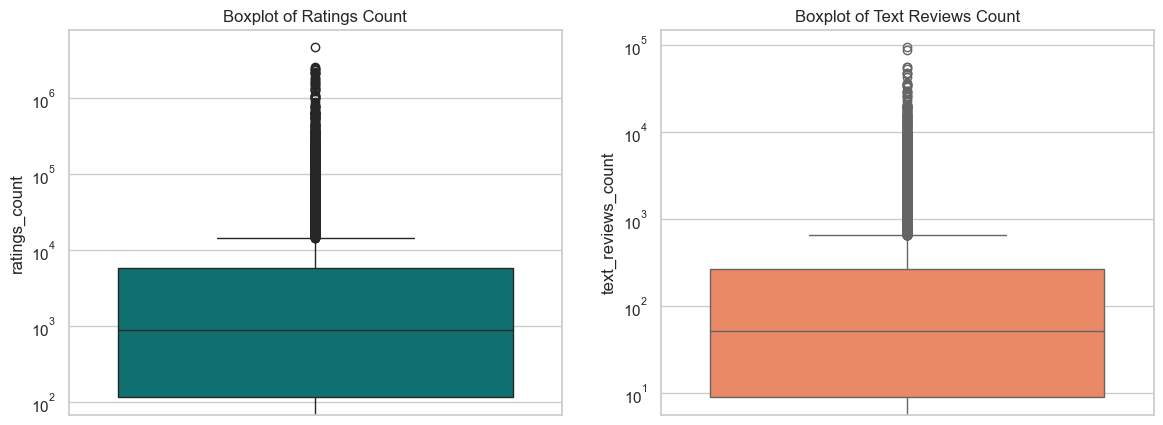

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['ratings_count'], ax=ax[0], color='teal')
ax[0].set_title('Boxplot of Ratings Count')
ax[0].set_yscale('log') 

sns.boxplot(y=df['text_reviews_count'], ax=ax[1], color='coral')
ax[1].set_title('Boxplot of Text Reviews Count')
ax[1].set_yscale('log')

plt.show()

We used a log transform because the superstar books have numbers in the millions and normal books have numbers in the hundreds, the massive gap will confuse traditional ML models.

The nearly identical shape, median placement, and outlier distributions between both boxplots hypothesize an incredibly strong linear correlation between `ratings_count` and `text_reviews_count`. We must test this with a correlation matrix, as including both raw features could introduce damaging multicollinearity.

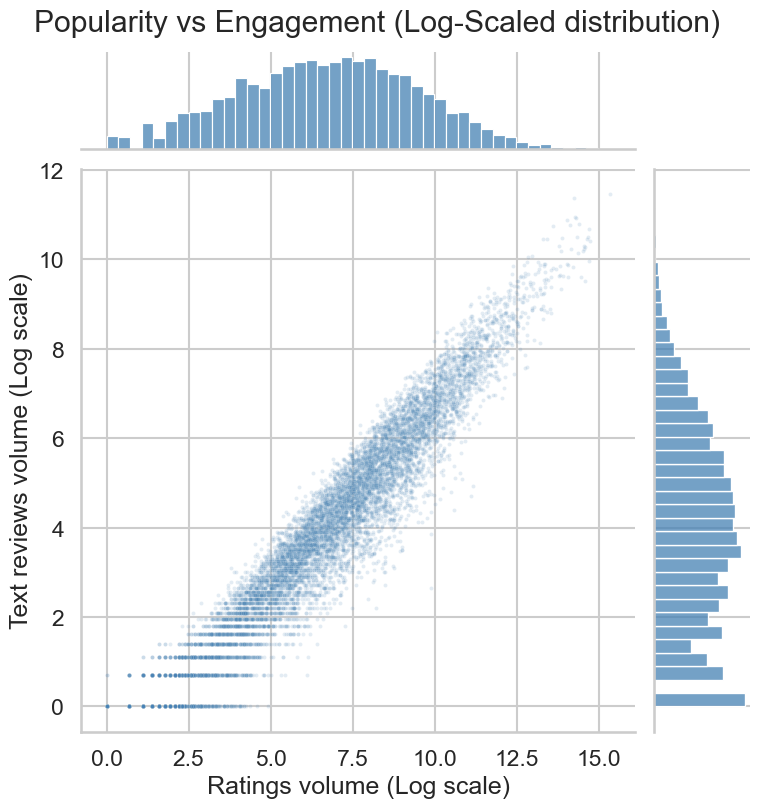

In [45]:
sns.set_context('talk')
sns.set_style("whitegrid")

log_ratings = np.log1p(df['ratings_count'])
log_reviews = np.log1p(df['text_reviews_count'])

g = sns.jointplot(
    x=log_ratings, 
    y=log_reviews, 
    kind='scatter', 
    alpha=0.15, 
    s=8, 
    color='steelblue',
    height=8
)

g.fig.suptitle('Popularity vs Engagement (Log-Scaled distribution)', y=1.02)
g.set_axis_labels('Ratings volume (Log scale)', 'Text reviews volume (Log scale)')

plt.show()

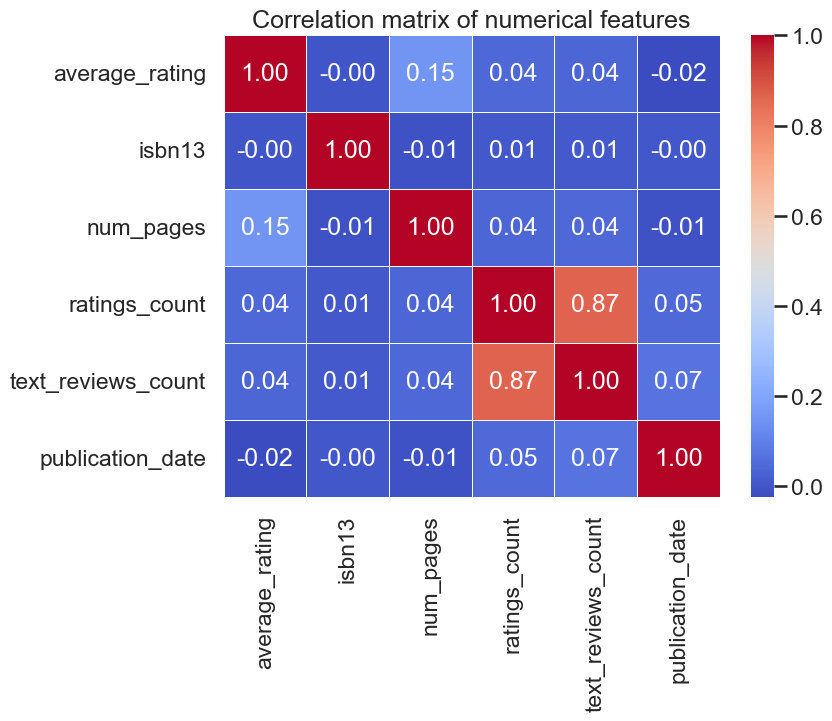

In [47]:
plt.figure(figsize=(8, 6))
numerical_cols = ['average_rating', 'isbn13', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation matrix of numerical features')
plt.show()

The 0.87 correlation between `ratings_count` and `text_reviews_count` presents a classic case of multicollinearity. For traditional linear or distance-based ML algorithms, keeping both raw features will destabilize feature coefficients. 

The `average_rating` displays near-zero linear correlation coefficients across the board, traditional Linear Regression will likely struggle to find a good fit. This strongly implies that the relationships in our book data are non-linear, meaning tree-based models (like Random Forests or Gradient Boosting) will be required to capture underlying patterns.

Features like `isbn13` display absolute zero correlation across all other columns. This confirms that identifiers carry no predictive value for user ratings and should be completely stripped from the feature space before model training to prevent overfitting on arbitrary ID patterns.

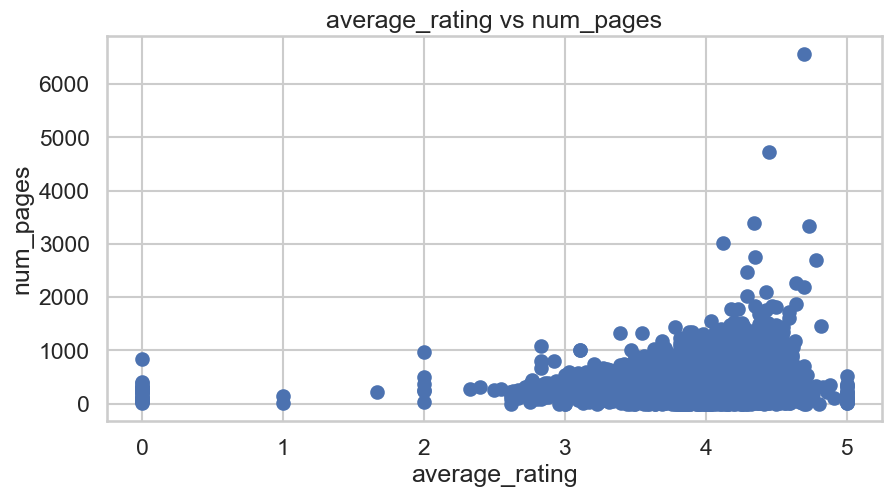

In [48]:
plt.figure(figsize=(10,5))
plt.scatter(df.average_rating,df.num_pages)
plt.title("average_rating vs num_pages")
plt.xlabel("average_rating")
plt.ylabel("num_pages")
plt.show()

Massive books are mathematically superior because they have zero bad ratings. If a casual reader picks up a giant book and finds it boring, they don't force themselves to finish all 2000 pages. Crucially, because they didn't finish it, they usually don't bother leaving a rating. The only readers who actually stick around until page 2000 are the ultimate superfans of that specific author or fantasy universe. They already love the characters and the story, so they are practically guaranteed to leave a 4 or 5-star review at the end.

Page length does not linearly increase a book's score. Tree-based ML algorithms will naturally exploit this thresholding behavior far better than linear models.

In [49]:
unrated_books = df[df['average_rating'] == 0]
unrated_books

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
265,799,out to eat london 2002 (lonely planet out to eat),Lonely Planet/Mark Honan,0.0,1740592050,9781740592055,eng,295,0,0,2001-09-01,lonely planet
375,1302,juiced official strategy guide,Doug Walsh,0.0,0744005612,9780744005615,eng,112,0,0,2005-06-01,bradygames
987,3351,open city 6: the only woman he ever left,Open City Magazine/James Purdy/Daniel Pinchbec...,0.0,189044717X,9781890447175,eng,200,0,0,2000-10-13,grove press open city books
2532,9337,how to meditate: an anthology of talks on medi...,Frederick P. Lenz,0.0,1932206108,9781932206104,eng,228,0,0,2004-01-01,frederick p. lenz foundation for american budd...
2533,9338,insights: talks on the nature of existence,Frederick P. Lenz,0.0,1932206086,9781932206081,eng,304,0,0,2003-01-01,frederick p. lenz foundation for american budd...
3493,12712,brodie's notes on aldous huxley's brave new world,Graham Handley,0.0,0333581296,9780333581292,eng,71,0,0,1992-08-20,macmillan
4242,15186,american film guide,Frank N. Magill,0.0,0893562505,9780893562502,eng,5,0,0,1983-01-01,salem press inc
4678,16806,the man and the author: john milton: twentieth...,J. Martin Evans,0.0,0415940478,9780415940474,eng,386,0,0,2002-11-08,routledge
5325,19257,canopy: a work for voice and light in harvard ...,David Ward/Parveen Adams/Seamus Heaney/Ivan Ga...,0.0,0916724948,9780916724948,eng,63,0,0,1997-12-31,arts publications
6383,24010,"laguna i love you: the best of ""our town""",John Weld/Phil Interlandi,0.0,1564741575,9781564741578,eng,285,0,0,1996-03-01,fithian press


This isn't because those are terrible books. It's because nobody has read it yet, or it represents a structural absence of data.

Keeping these 0.0 values will severely penalize the models' ability to learn what makes a book "good" or "bad". So we should drop them from our training data, as unrated books don't provide a meaningful target signal for a rating predictor.

Additionally, we are going to keep these 0-rating books in a separate dataframe called `unrated_books`. And once our model is fully trained and highly accurate, we can actually use it to predict what their ratings should be.

In [50]:
unrated_books.shape

(24, 12)

In [51]:
df = df[df['average_rating'] != 0]

In [52]:
df.shape

(10188, 12)

In [53]:
zero_pages_books = df[df['num_pages'] == 0]
zero_pages_books.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
306,955,the 5 love languages / the 5 love languages jo...,Gary Chapman,4.70,0802415318,9780802415318,eng,0,22,4,2005-01-01,moody publishers
853,2835,the tragedy of pudd'nhead wilson,Mark Twain/Michael Prichard,3.79,140015068X,9781400150687,eng,0,3,0,2003-01-01,tantor media
1061,3593,murder by moonlight & other mysteries (new adv...,NOT A BOOK,4.00,0743564677,9780743564670,eng,0,7,2,2006-10-03,simon schuster audio
1064,3599,the unfortunate tobacconist & other mysteries ...,NOT A BOOK,3.50,074353395X,9780743533959,eng,0,12,1,2003-10-01,simon & schuster audio
1558,5362,the summons / the brethren,John Grisham/Michael Beck/Frank Muller,3.99,0739342770,9780739342770,eng,0,241,9,2006-10-10,random house audio


In [54]:
zero_pages_books.shape

(59, 12)

These zero values indicate either audiobook formats or upstream data scraping errors.

In [55]:
zero_pages_books['publisher'].value_counts()

publisher
random house audio                     13
macmillan audio                         4
simon & schuster audio                  3
random house value publishing           3
tantor media                            3
random house audio publishing group     3
audiogo                                 2
basic books                             2
rh audio                                2
ivy books                               2
listening library (audio)               2
warner adult                            1
harperaudio                             1
simon schuster audio                    1
moody publishers                        1
harpercollins publishers                1
knopf                                   1
grand central publishing                1
bbc audiobooks                          1
ballantine books                        1
schocken                                1
hachette audio                          1
blackstone audiobooks                   1
rh audio price-less     

In [56]:
audio_keywords = 'audio|audible|recorded|listening|tape'

is_audio_match = zero_pages_books['publisher'].str.lower().str.contains(audio_keywords, na=False)

audiobooks = zero_pages_books[is_audio_match]
physical_books = zero_pages_books[~is_audio_match]

print(f"Total number of rows with audiobooks: {len(audiobooks)}")
print(f"Total number of rows with physical books having 0 pages: {len(physical_books)}")

Total number of rows with audiobooks: 37
Total number of rows with physical books having 0 pages: 22


We'll address the 0-page problem for physical books by calculating the median page count for each specific author and filling these zero values.

In [57]:
physical_books.sort_values(by='title')

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
8956,34706,13th directorate,Barry Chubin,2.62,0804104557,9780804104555,eng,0,8,1,1989-02-28,ivy books
2105,7598,a study guide to gabriel garcia marquez' one h...,Gabriel García Márquez/Brenda K. Marshall/F. M...,4.11,1570421129,9781570421129,eng,0,75,2,2006-04-01,warner adult
2676,9832,blind willow sleeping woman: 24 stories,Haruki Murakami/Ellen Archer/Patrick Lawlor,3.84,1400102952,9781400102952,eng,0,28,3,2006-10-15,tantor media
4369,15691,caligula and three other plays,Albert Camus,4.04,039440520X,9780394405209,fre,0,17,3,1966-05-01,knopf
2711,9981,der prozess,Franz Kafka,3.98,0805232117,9780805232110,ger,0,2,0,1988-05-05,schocken
10192,41273,fine lines (one-eyed mack #6),Jim Lehrer,3.23,0517164353,9780517164358,eng,0,17,4,1995-11-19,random house value publishing
8993,34938,first king of shannara (shannara prequel),Terry Brooks,3.96,0517199963,9780517199961,eng,0,1,0,1996-03-19,random house value publishing
9123,35485,five rings of fire (able team #11),Tom Arnett/Dick Stivers/Don Pendleton,3.64,0373612117,9780373612116,eng,0,39,2,1984-02-23,gold eagle
7610,29253,here we all are,Ram Dass/Richard Alpert,4.21,1401910440,9781401910440,en-GB,0,61,6,2005-12-15,hay house
4525,16312,one two buckle my shoe (hercule poirot #23),Agatha Christie/Hugh Fraser,3.76,1572703857,9781572703858,eng,0,14388,411,2004-03-16,harpercollins publishers


In [58]:
broken_authors = physical_books['authors'].unique()
broken_authors

array(['Gary Chapman', 'Mark Twain/Michael Prichard',
       'Gabriel García Márquez/Brenda K. Marshall/F. Murray Abraham',
       'William Arrow', 'H.G. Wells',
       'Haruki Murakami/Ellen Archer/Patrick Lawlor', 'Franz Kafka',
       'James Redfield/Lou Diamond Phillips', 'Albert Camus',
       'Agatha Christie/Hugh Fraser', 'Richard P. Feynman',
       'Frank Graham', 'Ram Dass/Richard Alpert', 'Barry Chubin',
       'Terry Brooks', 'Tom Arnett/Dick Stivers/Don Pendleton',
       'Georgina Grey', 'John Grisham', 'Edgar Rice Burroughs/John Bolen',
       'Jim Lehrer', 'Victoria Holt'], dtype=object)

In [59]:
authors_global_data = df[df['authors'].isin(broken_authors)]

author_audit = authors_global_data.groupby(['authors']).agg(
    total_books_in_dataset=('num_pages', 'count'),
    median_page_count=('num_pages', lambda x: x[x > 0].median()),
    min_page_count=('num_pages', 'min')
)

print(author_audit)

                                                    total_books_in_dataset  \
authors                                                                      
Agatha Christie/Hugh Fraser                                              4   
Albert Camus                                                             6   
Barry Chubin                                                             1   
Edgar Rice Burroughs/John Bolen                                          2   
Frank Graham                                                             1   
Franz Kafka                                                              2   
Gabriel García Márquez/Brenda K. Marshall/F. Mu...                       1   
Gary Chapman                                                             1   
Georgina Grey                                                            1   
H.G. Wells                                                               5   
Haruki Murakami/Ellen Archer/Patrick Lawlor                     

Instead of injecting random values that would cause the model to learn incorrectly, we'll drop the rows where the author only has that single, unfixable book.

In [60]:
author_audit[author_audit['median_page_count'].isna()].shape

(9, 3)

In [61]:
clean_median = author_audit.groupby('authors')['median_page_count'].median()

author_median = clean_median.round().fillna(-1).astype(int)

df.loc[(df['num_pages'] == 0) & (~is_audio_match), 'num_pages'] = df.loc[(df['num_pages'] == 0) & (~is_audio_match), 'authors'].map(author_median)

df = df[df['num_pages'] != -1]

In [62]:
df.shape

(10179, 12)

Now let's deal with the remaining audiobooks.

In [63]:
df[df['num_pages'] == 0]

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
1061,3593,murder by moonlight & other mysteries (new adv...,NOT A BOOK,4.00,0743564677,9780743564670,eng,0,7,2,2006-10-03,simon schuster audio
1064,3599,the unfortunate tobacconist & other mysteries ...,NOT A BOOK,3.50,074353395X,9780743533959,eng,0,12,1,2003-10-01,simon & schuster audio
1558,5362,the summons / the brethren,John Grisham/Michael Beck/Frank Muller,3.99,0739342770,9780739342770,eng,0,241,9,2006-10-10,random house audio
1842,6542,the patricia cornwell cd audio treasury: all t...,Patricia Cornwell/Kate Burton,4.16,0060791217,9780060791216,eng,0,202,1,2005-07-26,harperaudio
2129,7674,the michael crichton collection: airframe / th...,Michael Crichton/Stephen Lang/Anthony Heald/Bl...,4.16,0739340336,9780739340332,en-GB,0,267,7,2006-08-29,random house audio
2732,10075,clockwork (cover to cover),Philip Pullman,3.87,185549695X,9781855496958,eng,0,24,1,2002-07-29,bbc audiobooks
2858,10599,gray matter and other stories from night shift,Stephen King/John Glover,3.93,055347183X,9780553471830,eng,0,156,9,1993-08-01,random house audio
4526,16313,a caribbean mystery,Agatha Christie/Rosalind Ayres,3.80,1572705493,9781572705494,eng,0,49,10,2006-10-09,audiogo
4536,16334,the listerdale mystery and eleven other stories,Agatha Christie/Hugh Fraser,3.56,1572704977,9781572704978,eng,0,1824,89,2006-01-11,audiogo
4921,17766,master and commander (aubrey/maturin book 1),Patrick O'Brian,4.10,073931565X,9780739315651,eng,0,1,0,2004-03-09,random house audio


When dealing with these audiobooks, we technically have two choices. We could keep them and add an `is_audiobook` column, but that flag really only helps tree-based models. For neural networks or linear models, having a bunch of "0" page counts completely messes up the math and confuses the learning process. 

Plus, looking at the numbers, there are only 37 of these rows out of our entire book dataset. Keeping such a tiny fraction of data isn't worth the risk of distorting our models, so we are dropping them entirely to keep things clean and uniform for every model we try.

In [64]:
df = df[df['num_pages'] != 0]

In [65]:
df.shape

(10142, 12)

Let's check if there left any other audiobooks in the whole dataset.

In [66]:
is_audio_match_global = df['publisher'].str.lower().str.contains(audio_keywords, na=False)

all_audiobooks = df[is_audio_match_global]

all_audiobooks

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
673,2166,the old man and the sea,Ernest Hemingway/Donald Sutherland,3.77,0743564367,9780743564366,eng,3,393,77,2006-05-01,simon schuster audio
720,2326,dirk gently's holistic detective agency (dirk ...,Douglas Adams,3.98,1597770078,9781597770071,eng,6,58,15,2005-09-30,phoenix audio
741,2389,moby dick,Herman Melville/William Hootkins,3.50,0143058096,9780143058090,eng,6,8858,885,2005-06-16,penguin audio
1165,3875,the sun also rises,Ernest Hemingway/William Hurt,3.82,0743564413,9780743564410,eng,8,302,69,2006-10-17,simon schuster audio
1451,5065,whiteout,Ken Follett/David Tennant,3.58,1405052716,9781405052719,eng,4,13,1,2006-09-01,macmillan audio
...,...,...,...,...,...,...,...,...,...,...,...,...
10744,43819,anne rice value collection: mayfair witches (l...,Anne Rice/Joe Morton/Tim Curry/Lindsay Crouse,4.23,037541620X,9780375416200,eng,10,35,3,2000-11-07,random house audio publishing group
10840,44231,the silver pigs,Lindsey Davis/Mary Cutler/Anton Lesser/Fritha ...,3.94,056352569X,9780563525691,eng,2,5,0,2005-02-07,bbc audiobooks
10875,44470,the killer angels,Michael Shaara/Stephen Hoye,4.32,0739309056,9780739309056,en-US,13,92,37,2004-05-11,random house audio publishing group
11102,45549,undaunted courage,Stephen E. Ambrose/Barrett Whitener,4.21,1415918090,9781415918098,eng,22,8,2,2005-03-08,books on tape


These records perfectly illustrate why audio formats completely break numerical logic.

In reality, these aren't corrupted data points, they are audiobooks that will completely ruin the models' ability to learn a stable relationship between book length and reader ratings.

More importantly, when people review an audiobook, they are heavily factoring in the performance of the narrator. A bad narrator can ruin a great book, and a legendary one can elevate a mediocre one. Our model only looks at features like the title, authors, and publisher, it has no way to understand or measure the "voice acting quality."

Since these represent a tiny sliver of our dataset, we'll drop them to keep our feature relationships mathematically sound across all model architectures.

In [67]:
df = df.drop(all_audiobooks.index)

In [68]:
df.shape

(10053, 12)

Now let's deal with the zero rating counts problem.

In [69]:
zero_ratings_count = df[df['ratings_count'] == 0]
zero_ratings_count.sort_values(by='authors')

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
7754,29927,a farewell to arms?: beyond the good friday ag...,Adrian Guelke/Michael Cox/Fiona Stephen,4.33,0719071151,9780719071157,eng,624,0,0,2006-04-18,manchester university press
4214,15066,it's only a movie ingrid: encounters on and of...,Alexander Walker,3.80,0747230218,9780747230212,eng,320,0,0,1989-08-17,headline book publishing
3235,11861,city on the seine: paris in the time of richel...,Andrew P. Trout,4.17,0333666380,9780333666388,eng,288,0,0,1996-06-05,palgrave macmillan
8766,33775,kopfüber ins glück,Anna Maxted,3.54,3442454085,9783442454082,ger,512,0,0,2003-02-01,goldmann
10853,44321,a cargo of women: susannah watson and the conv...,Babette Smith,3.58,1877058335,9781877058332,eng,264,0,0,2005-06-01,rosenberg publishing
10866,44433,courageous faith through the year,Bill Hybels/Keri Wyatt Kent,3.50,0830832947,9780830832941,eng,327,0,0,2004-07-01,ivp books
2956,10939,ya sé que te quiero,Billy Crystal/Elizabeth Sayles,4.19,0060845988,9780060845988,spa,40,0,0,2006-04-11,rayo
1681,5863,v.s. naipaul,Bruce Alvin King,2.00,1403904561,9781403904560,eng,240,0,0,2003-10-10,palgrave macmillan
2051,7400,the baby emergency (tennengarrah clinic #1),Carol Marinelli,3.60,0263181499,9780263181494,eng,285,0,0,2004-06-01,mills & boon
4856,17506,la gata perdida = the missing cat (las aventur...,Chris L. Demarest/Berlitz Publishing Company,4.14,9812468234,9789812468239,spa,64,0,0,2006-08-15,berlitz kids


Mathematically, it is completely impossible to have a true average rating of 4.03 or 5.00 if exactly 0 people have rated the book. An average requires a sum divided by a count. If the count is 0, the math divides by zero, which means either these average rating numbers are completely fake or the number of people who clicked the rating button for this book is just missing or wasn't tracked.

Spot-checking some of these titles on `Goodreads` confirms that their `average_rating` scores are valid, but the accompanying `ratings_count` data is missing from our dataset copy.

Since our models need to learn how popularity (`ratings_count`) affects the `average_rating`, leaving these as 0 will teach the models completely contradictory and chaotic rules. So We'll address this problem by calculating the median ratings count for each specific author and filling these zero values.

In [70]:
authors = zero_ratings_count['authors'].unique()
authors

array(['Lonely Planet/Sarah Johnstone/Tom Masters',
       "Karen O'Connor/Larry J. Sabato", 'Julian Markels',
       'Elizabeth von Arnim', 'Ian Fleming', 'Bruce Alvin King',
       'Carol Marinelli', 'Judi Barrett/Ron Barrett',
       'Billy Crystal/Elizabeth Sayles', 'Jason Hook',
       'Roald Dahl/Quentin Blake', 'Dan Simmons/Jean-Daniel Brèque',
       'Andrew P. Trout', 'Robert L. Geneve', 'SparkNotes',
       'João Guimarães Rosa', 'Alexander Walker',
       'Chris L. Demarest/Berlitz Publishing Company',
       'Greg Tang/Heather Cahoon',
       'James Ellroy/Otto Penzler/John Biguenet/Michael Connelly/Thomas H. Cook/Sean Doolittle/Brendan DuBois/David Edgerley Gates/Joe Gores/James Grady/Clark Howard/Stuart M. Kaminsky/Joe R. Lansdale/Michael Malone/Annette Meyers/Joyce Carol Oates/Robert B. Parker/F.X. Toole/Daniel Waterman/Scott Wolven/Fred Melton',
       'Rumiko Takahashi', 'Gordon Korman', 'T. Coraghessan Boyle',
       'Christopher Black/Mark Anestis', 'Eleanor J. Gibso

In [71]:
authors_global = df[df['authors'].isin(authors)]

author_audit_rating = authors_global.groupby(['authors']).agg(
    total_books_in_dataset=('ratings_count', 'count'),
    median_ratings_count=('ratings_count', lambda x: x[x > 0].median()),
)

author_audit_rating

,total_books_in_dataset,median_ratings_count
authors,,
Adrian Guelke/Michael Cox/Fiona Stephen,1,NaN
Alexander Walker,1,NaN
Andrew P. Trout,1,NaN
Anna Maxted,5,1369.0
Babette Smith,1,NaN
Bill Hybels/Keri Wyatt Kent,1,NaN
Billy Crystal/Elizabeth Sayles,1,NaN
Bruce Alvin King,1,NaN
Carol Marinelli,1,NaN


In [72]:
author_audit_rating[author_audit_rating['median_ratings_count'].isna()].shape

(31, 2)

Instead of injecting random values that would cause the model to learn incorrectly, we'll drop the rows where the author only has that single, unfixable book.

In [73]:
clean_median_series = author_audit_rating.groupby('authors')['median_ratings_count'].median()

authors_median = clean_median_series.round().fillna(-1).astype(int)

df.loc[df['ratings_count'] == 0, 'ratings_count'] = df.loc[df['ratings_count'] == 0, 'authors'].map(authors_median)

df = df[df['ratings_count'] != -1]

In [74]:
df

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,harry potter and the half-blood prince (harry ...,J.K. Rowling,4.57,0439785960,9780439785969,eng,652,2095690,27591,2006-09-16,scholastic inc.
1,2,harry potter and the order of the phoenix (har...,J.K. Rowling,4.49,0439358078,9780439358071,eng,870,2153167,29221,2004-09-01,scholastic inc.
3,5,harry potter and the prisoner of azkaban (harr...,J.K. Rowling,4.56,043965548X,9780439655484,eng,435,2339585,36325,2004-05-01,scholastic inc.
4,8,harry potter boxed set books 1-5 (harry potter...,J.K. Rowling,4.78,0439682584,9780439682589,eng,2690,41428,164,2004-09-13,scholastic
5,9,"unauthorized harry potter book seven news: ""ha...",W. Frederick Zimmerman,3.74,0976540606,9780976540601,en-US,152,19,1,2005-04-26,nimble books
...,...,...,...,...,...,...,...,...,...,...,...,...
11122,45631,expelled from eden: a william t. vollmann reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,1560254416,9781560254416,eng,512,156,20,2004-12-21,da capo press
11123,45633,you bright and risen angels,William T. Vollmann,4.08,0140110879,9780140110876,eng,635,783,56,1988-12-01,penguin books
11124,45634,the ice-shirt (seven dreams #1),William T. Vollmann,3.96,0140131965,9780140131963,eng,415,820,95,1993-08-01,penguin books
11125,45639,poor people,William T. Vollmann,3.72,0060878827,9780060878825,eng,434,769,139,2007-02-27,ecco
